#### Setup and load all CSVs

In [1]:
%matplotlib inline
import os
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 140
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["legend.fontsize"] = 10
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
plt.rcParams.update({
    "grid.linestyle": "--",
    "grid.alpha": 0.3,
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"], 
})

# --------------------------------------------------
# Paths
# --------------------------------------------------
BASE_DIR = Path("/data/local/rgaisina/experiments_final/geirhos_texture_plus_edges/meta")
FIG_DIR = BASE_DIR / "figures_eval_all_models_1"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# --------------------------------------------------
# Models
# --------------------------------------------------
MODEL_FILES = {
    "resnet18": "eval_geirhos_texture_plus_edges_resnet18_a1_in1k_top5.csv",
    "resnet50": "eval_geirhos_texture_plus_edges_resnet50_a1_in1k_top5.csv",
    "vit_tiny": "eval_geirhos_texture_plus_edges_vit_tiny_patch16_224_augreg_in21k_ft_in1k_top5.csv",
    "vit_base": "eval_geirhos_texture_plus_edges_vit_base_patch16_224_augreg_in21k_ft_in1k_top5.csv",
}

MODEL_ORDER = ["resnet18", "resnet50", "vit_tiny", "vit_base"]

MODEL_DISPLAY = {
    "resnet18": "ResNet-18",
    "resnet50": "ResNet-50",
    "vit_tiny": "ViT-Tiny",
    "vit_base": "ViT-Base",
}

#### Helper to load and standardize one CSV

In [2]:
def load_model_csv(csv_path: Path, model_key: str) -> pd.DataFrame:
    df = pd.read_csv(csv_path).copy()
    df["model"] = model_key

    # backward compatibility
    if "decision_top1" not in df.columns and "decision" in df.columns:
        df["decision_top1"] = df["decision"]

    if "decision_top5" not in df.columns:
        if "shape_in_top5" in df.columns and "texture_in_top5" in df.columns:
            def d5(row):
                s = bool(row["shape_in_top5"])
                t = bool(row["texture_in_top5"])
                if s and t:
                    return "both"
                if t:
                    return "texture"
                if s:
                    return "shape"
                return "other"
            df["decision_top5"] = df.apply(d5, axis=1)
        else:
            df["decision_top5"] = "other"

    # ensure numeric columns exist
    for col in ["logit_shape", "logit_texture", "prob_shape", "prob_texture", "prob_top1"]:
        if col not in df.columns:
            df[col] = np.nan

    # derived columns
    df["logit_margin_tex_minus_shape"] = df["logit_texture"] - df["logit_shape"]
    df["prob_margin_tex_minus_shape"] = df["prob_texture"] - df["prob_shape"]

    # your original condition naming
    df["condition"] = df["shape_name"].astype(str) + " + " + df["texture_name"].astype(str)

    return df

In [3]:
dfs = []

for model_key in MODEL_ORDER:
    csv_path = BASE_DIR / MODEL_FILES[model_key]
    if not csv_path.exists():
        raise FileNotFoundError(f"Missing CSV for {model_key}: {csv_path}")

    df_model = load_model_csv(csv_path, model_key)
    dfs.append(df_model)

df_all = pd.concat(dfs, ignore_index=True)

print("Loaded rows:", len(df_all))
print("Models:", df_all["model"].value_counts().to_dict())
print("Columns:", sorted(df_all.columns.tolist()))
df_all.head(3)

Loaded rows: 2880
Models: {'resnet18': 720, 'resnet50': 720, 'vit_tiny': 720, 'vit_base': 720}
Columns: ['condition', 'decision_top1', 'decision_top5', 'image_id', 'img_path', 'logit_margin_tex_minus_shape', 'logit_shape', 'logit_texture', 'mode', 'model', 'parent_prob_mass', 'parent_top1_match', 'parent_top5_match', 'pred_idx', 'pred_label', 'pred_parent', 'pred_wnid', 'prob_margin_tex_minus_shape', 'prob_shape', 'prob_texture', 'prob_top1', 'shape_idx', 'shape_in_top5', 'shape_name', 'shape_parent', 'shape_wnid', 'texture_idx', 'texture_in_top5', 'texture_name', 'texture_wnid', 'top1_logit_minus_shape_logit', 'top1_logit_minus_texture_logit']


,mode,image_id,shape_name,shape_wnid,texture_name,texture_wnid,shape_parent,pred_parent,decision_top1,decision_top5,...,prob_shape,prob_texture,prob_top1,top1_logit_minus_shape_logit,top1_logit_minus_texture_logit,img_path,model,logit_margin_tex_minus_shape,prob_margin_tex_minus_shape,condition
0,geirhos,ILSVRC2012_val_00001368,hen_bird,n01514859,chain_mail,n03000247,bird,n03000247,texture,texture,...,0.001475,0.898406,0.898406,6.411901,0.000000,/data/local/rgaisina/experiments_final/geirhos...,resnet18,6.411901,0.896931,hen_bird + chain_mail
1,geirhos,ILSVRC2012_val_00001368,hen_bird,n01514859,peacock,n01806143,bird,bird,texture,both,...,0.000529,0.992182,0.992182,7.536736,0.000000,/data/local/rgaisina/experiments_final/geirhos...,resnet18,7.536737,0.991653,hen_bird + peacock
2,geirhos,ILSVRC2012_val_00001368,hen_bird,n01514859,tiger,n02129604,bird,bird,other,shape,...,0.058853,0.007737,0.425283,1.977706,4.006696,/data/local/rgaisina/experiments_final/geirhos...,resnet18,-2.028990,-0.051116,hen_bird + tiger


#### Decision bar chart summary across models

In [4]:
def decision_percent_summary(df: pd.DataFrame, decision_col: str, model_order=None) -> pd.DataFrame:
    if model_order is None:
        model_order = sorted(df["model"].unique())

    if decision_col == "decision_top5":
        categories = ["texture", "shape", "both", "other"]
    else:
        categories = ["texture", "shape", "other"]

    rows = []
    for model in model_order:
        sub = df[df["model"] == model]
        counts = Counter(sub[decision_col].fillna("other").tolist())
        total = len(sub)

        row = {"model": model, "n": total}
        for cat in categories:
            row[cat] = 100.0 * counts.get(cat, 0) / total if total > 0 else np.nan
        rows.append(row)

    return pd.DataFrame(rows), categories

#### Grouped bar positions

In [5]:
def grouped_bar_positions(n_groups, n_bars, width=0.18):
    x = np.arange(n_groups)
    offsets = (np.arange(n_bars) - (n_bars - 1) / 2) * width
    return x, offsets

#### Plot grouped decision bar chart for all 4 models

In [6]:
def plot_grouped_decision_bars(df: pd.DataFrame, decision_col: str, title: str, outpath=None):
    summary, categories = decision_percent_summary(df, decision_col, MODEL_ORDER)

    x, offsets = grouped_bar_positions(
        n_groups=len(categories),
        n_bars=len(MODEL_ORDER),
        width=0.18
    )

    fig, ax = plt.subplots(figsize=(10, 6))

    for i, model in enumerate(MODEL_ORDER):
        sub = summary[summary["model"] == model].iloc[0]
        y = [sub[c] for c in categories]

        bars = ax.bar(
            x + offsets[i],
            y,
            width=0.18,
            label=MODEL_DISPLAY[model]
        )

        for bar in bars:
            h = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                h + 0.8,
                f"{h:.1f}%",
                ha="center",
                va="bottom",
                fontsize=8
            )

    ax.set_xticks(x)
    ax.set_xticklabels(categories)
    ax.set_ylabel("Percent of images (%)")
    ax.set_xlabel("Decision category")
    ax.set_ylim(0, 100)
    ax.set_title(title, pad=12)

    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.98), ncol=4, frameon=False)
    fig.subplots_adjust(top=0.84, bottom=0.14)

    if outpath:
        fig.savefig(outpath, bbox_inches="tight")
        print("Saved:", outpath)

    plt.show()
    plt.close(fig)

Saved: /data/local/rgaisina/experiments_final/geirhos_texture_plus_edges/meta/figures_eval_all_models_1/bar_top1_decisions_all_models.png


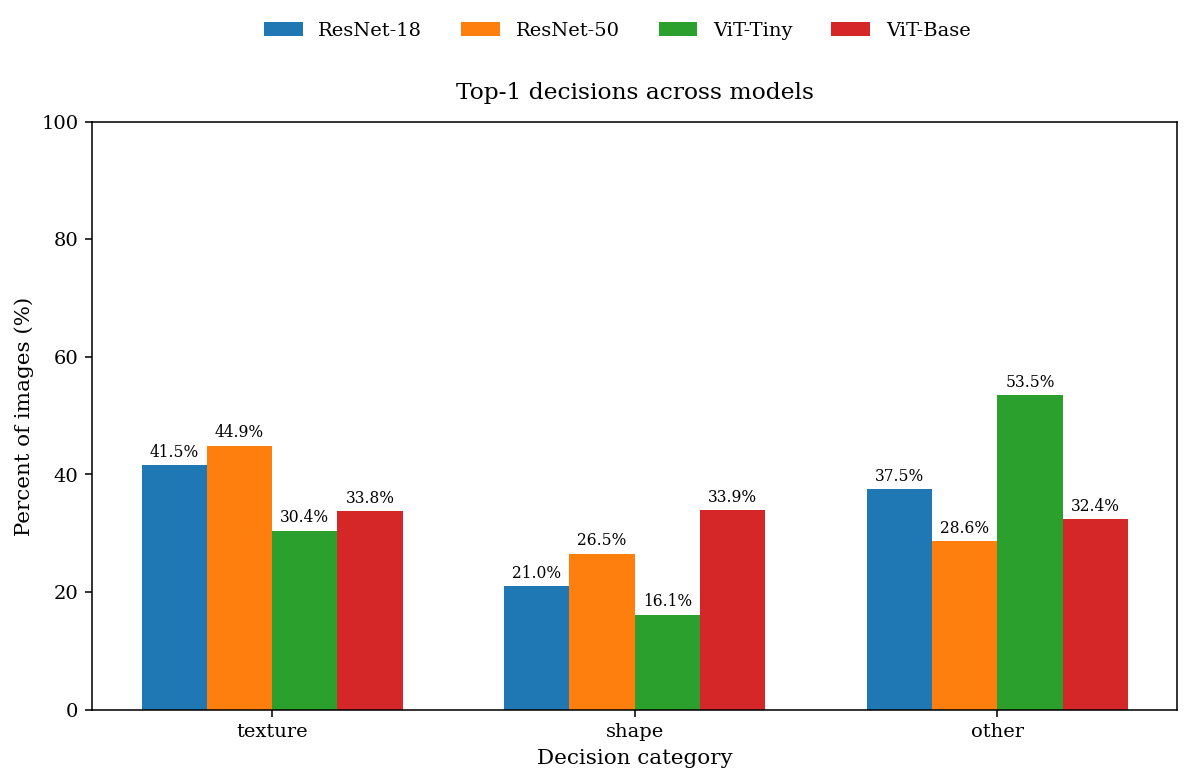

Saved: /data/local/rgaisina/experiments_final/geirhos_texture_plus_edges/meta/figures_eval_all_models_1/bar_top5_decisions_all_models.png


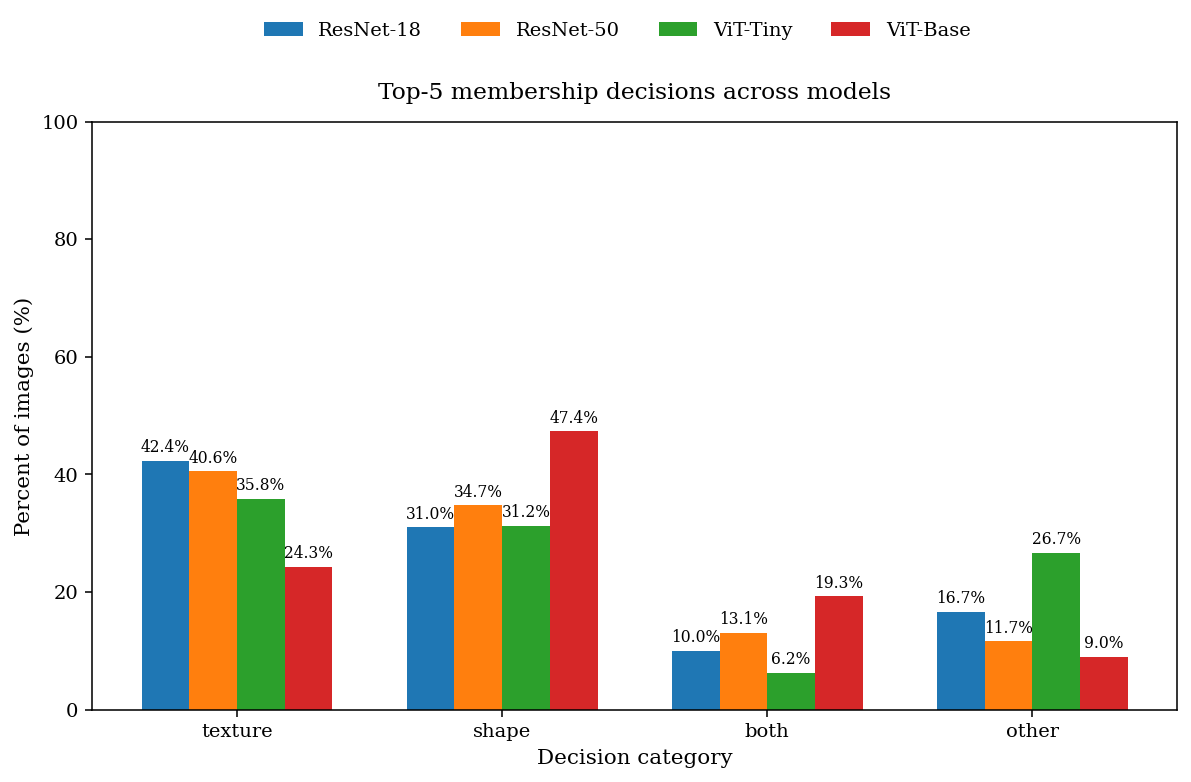

In [7]:
plot_grouped_decision_bars(
    df_all,
    "decision_top1",
    "Top-1 decisions across models",
    outpath=FIG_DIR / "bar_top1_decisions_all_models.png"
)

plot_grouped_decision_bars(
    df_all,
    "decision_top5",
    "Top-5 membership decisions across models",
    outpath=FIG_DIR / "bar_top5_decisions_all_models.png"
)

#### Shape bias as percentage

In [8]:
def shape_bias_from_decisions(series: pd.Series) -> float:
    counts = series.value_counts()
    shape_n = int(counts.get("shape", 0))
    texture_n = int(counts.get("texture", 0))
    denom = shape_n + texture_n
    return float(shape_n / denom * 100) if denom > 0 else np.nan

#### Summary table for shape bias by model and condition

In [9]:
df_all["condition_pair"] = df_all["shape_name"].astype(str) + " + " + df_all["texture_name"].astype(str)

In [10]:
summary_shape_bias = (
    df_all.groupby(["model", "condition_pair"])["decision_top1"]
    .apply(shape_bias_from_decisions)
    .reset_index(name="shape_bias_top1_pct")
)

summary_shape_bias.head()

,model,condition_pair,shape_bias_top1_pct
0,resnet18,african_elephant + chain_mail,0.0
1,resnet18,african_elephant + honeycomb,0.0
2,resnet18,african_elephant + peacock,0.0
3,resnet18,african_elephant + tiger,0.0
4,resnet18,african_elephant + zebra,0.0


#### Heatmap builder for one model

In [11]:
def build_decision_rate_grid(
    df_model: pd.DataFrame,
    decision_value: str,
    shape_order=None,
    texture_order=None,
):
    if shape_order is None:
        shape_order = sorted(df_model["shape_name"].unique().tolist())
    if texture_order is None:
        texture_order = sorted(df_model["texture_name"].unique().tolist())

    grid = np.full((len(shape_order), len(texture_order)), np.nan, dtype=float)

    for i, sh in enumerate(shape_order):
        for j, tx in enumerate(texture_order):
            sub = df_model[
                (df_model["shape_name"] == sh) &
                (df_model["texture_name"] == tx)
            ]

            if len(sub) == 0:
                continue

            grid[i, j] = 100.0 * (sub["decision_top1"] == decision_value).mean()

    return grid, shape_order, texture_order

In [12]:
def plot_top1_decision_heatmaps_2x2(
    df: pd.DataFrame,
    decision_value: str,
    title: str,
    outpath=None,
):
    shape_order = sorted(df["shape_name"].unique().tolist())
    texture_order = sorted(df["texture_name"].unique().tolist())

    grids = {}
    vmax = 0.0

    for model in MODEL_ORDER:
        df_model = df[df["model"] == model]
        grid, _, _ = build_decision_rate_grid(
            df_model,
            decision_value=decision_value,
            shape_order=shape_order,
            texture_order=texture_order,
        )
        grids[model] = grid

        if np.isfinite(grid).any():
            vmax = max(vmax, np.nanmax(grid))

    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    axes = axes.flatten()

    images = []

    for ax, model in zip(axes, MODEL_ORDER):
        grid = grids[model]

        im = ax.imshow(grid, aspect="auto", vmin=0, vmax=vmax, cmap="GnBu")
        images.append(im)

        ax.set_title(MODEL_DISPLAY[model])
        ax.set_xlabel("Texture class")
        ax.set_ylabel("Shape class")

        ax.set_xticks(np.arange(len(texture_order)))
        ax.set_yticks(np.arange(len(shape_order)))
        ax.set_xticklabels(texture_order, rotation=25, ha="right")
        ax.set_yticklabels(shape_order)

        for i in range(len(shape_order)):
            for j in range(len(texture_order)):
                val = grid[i, j]
                txt = "—" if np.isnan(val) else f"{val:.0f}"
                ax.text(j, i, txt, ha="center", va="center", fontsize=8)

    cbar = fig.colorbar(images[0], ax=axes, fraction=0.02, pad=0.03)
    cbar.set_label(f"Top-1 {decision_value} decision rate (%)")

    fig.suptitle(title, fontsize=15)
    fig.tight_layout(rect=[0, 0, 0.88, 0.96])

    if outpath:
        fig.savefig(outpath, bbox_inches="tight")
        print("Saved:", outpath)

    plt.show()
    plt.close(fig)

/tmp/ipykernel_3774022/842435554.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.88, 0.96])


Saved: /data/local/rgaisina/experiments_final/geirhos_texture_plus_edges/meta/figures_eval_all_models_1/heatmap_top1_texture_decision_all_models.png


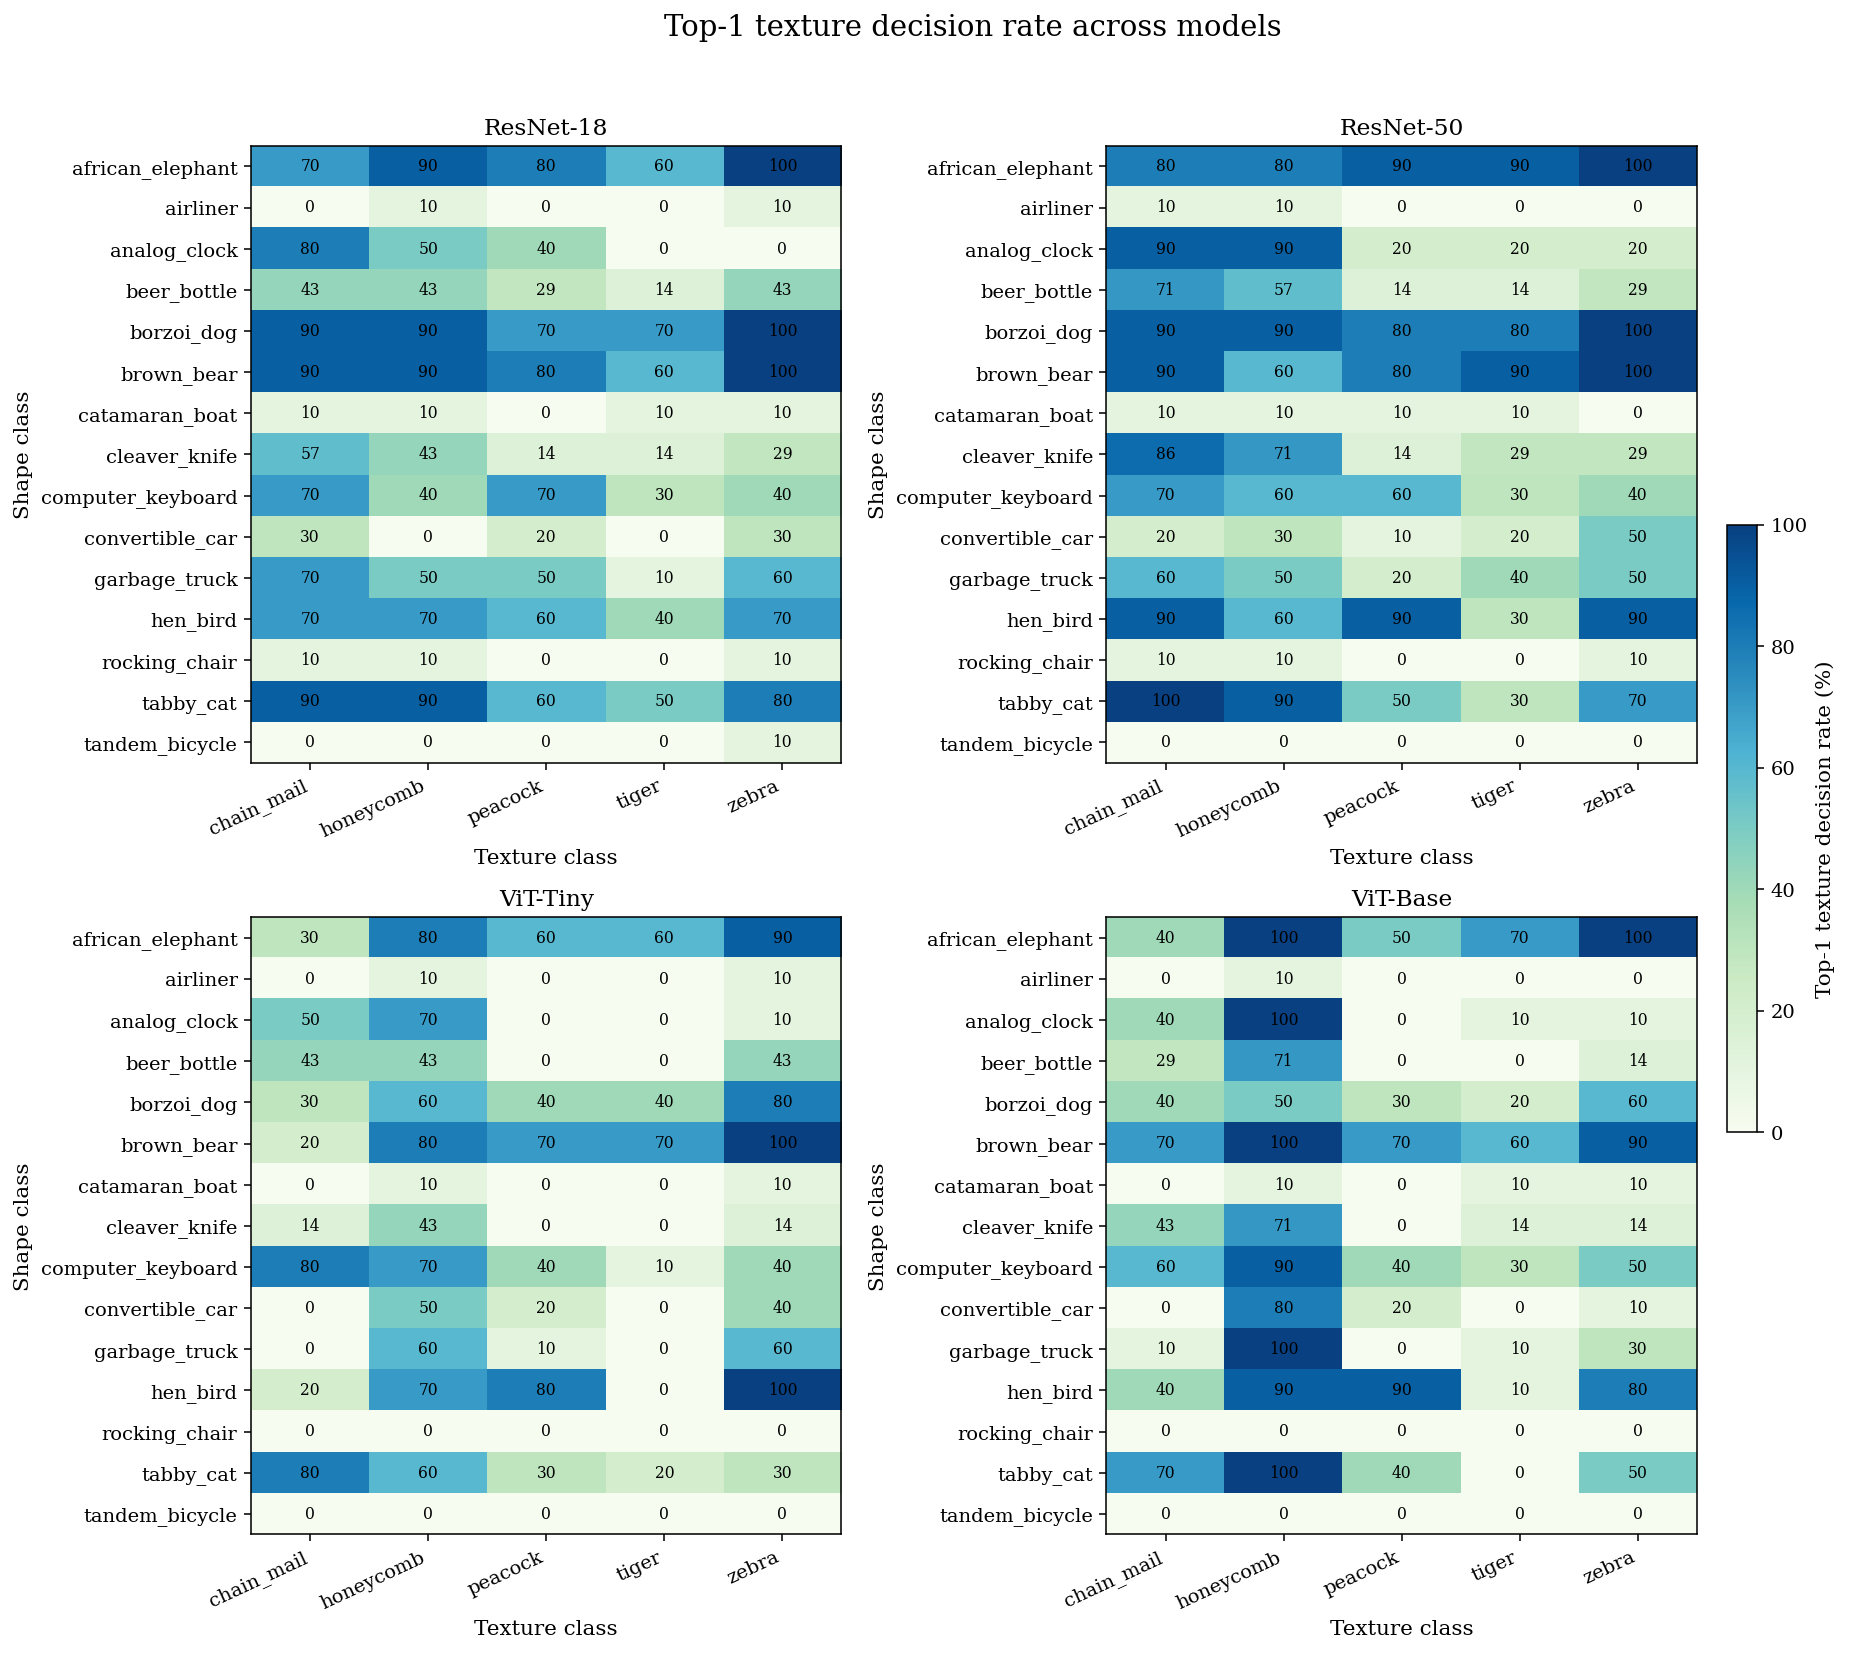

In [13]:
plot_top1_decision_heatmaps_2x2(
    df_all,
    decision_value="texture",
    title="Top-1 texture decision rate across models",
    outpath=FIG_DIR / "heatmap_top1_texture_decision_all_models.png"
)

/tmp/ipykernel_3774022/842435554.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.88, 0.96])


Saved: /data/local/rgaisina/experiments_final/geirhos_texture_plus_edges/meta/figures_eval_all_models_1/heatmap_top1_shape_decision_all_models.png


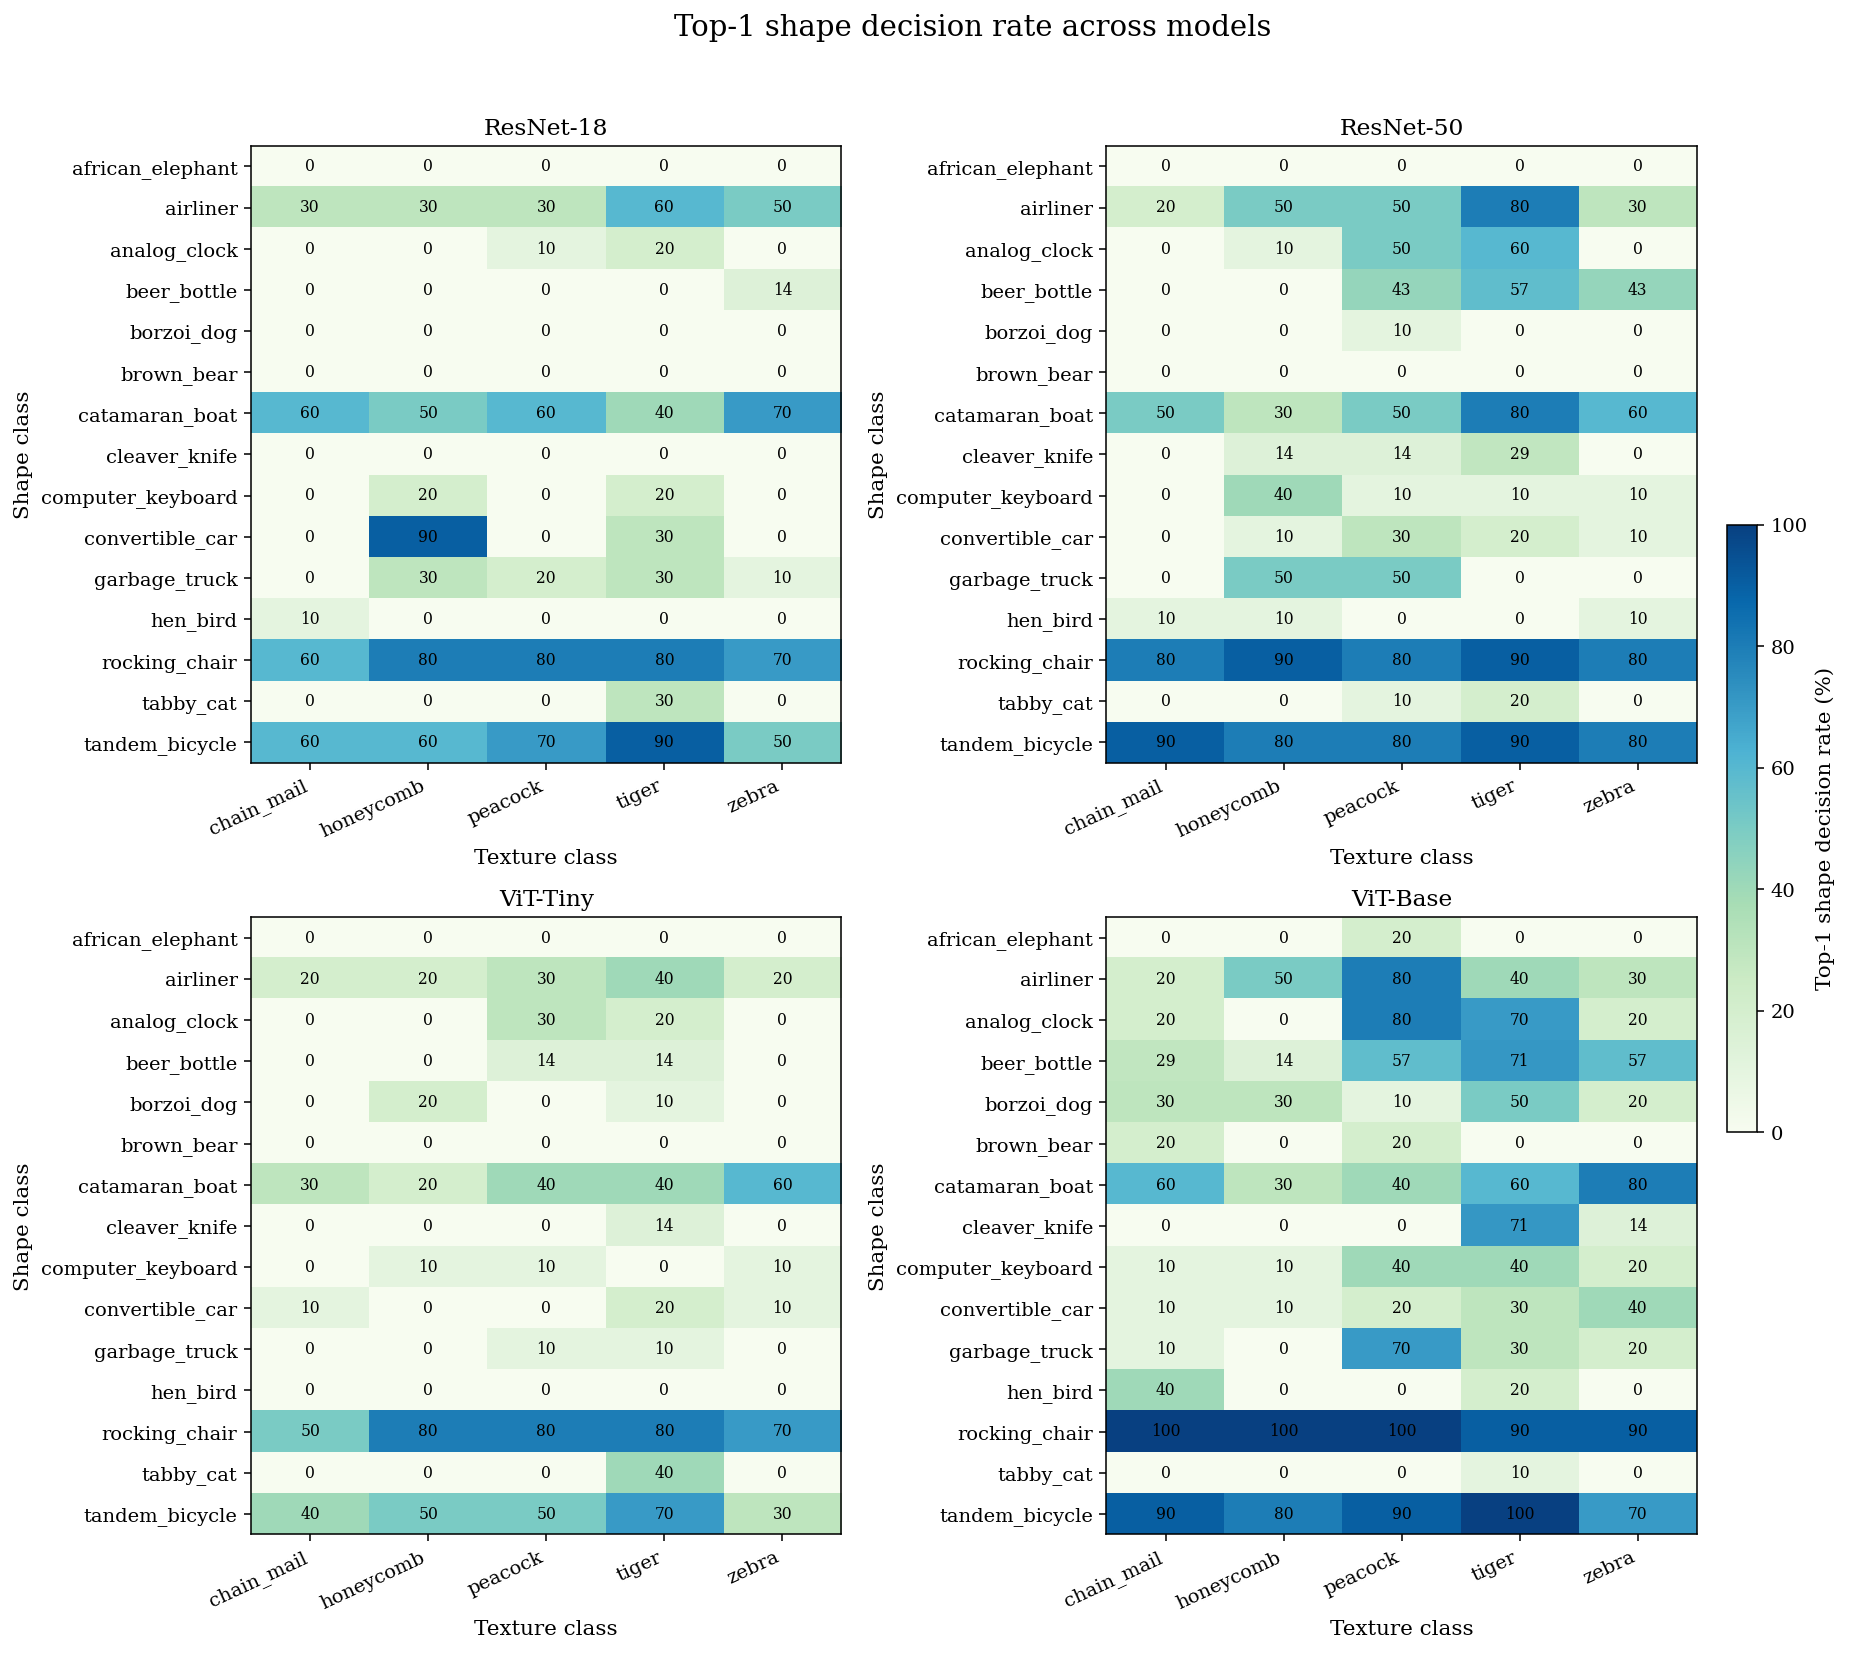

In [14]:
plot_top1_decision_heatmaps_2x2(
    df_all,
    decision_value="shape",
    title="Top-1 shape decision rate across models",
    outpath=FIG_DIR / "heatmap_top1_shape_decision_all_models.png"
)

In [15]:
def build_decision_top5_rate_grid(
    df_model: pd.DataFrame,
    decision_value: str,
    shape_order=None,
    texture_order=None,
):
    if shape_order is None:
        shape_order = sorted(df_model["shape_name"].unique().tolist())
    if texture_order is None:
        texture_order = sorted(df_model["texture_name"].unique().tolist())

    grid = np.full((len(shape_order), len(texture_order)), np.nan, dtype=float)

    for i, sh in enumerate(shape_order):
        for j, tx in enumerate(texture_order):
            sub = df_model[
                (df_model["shape_name"] == sh) &
                (df_model["texture_name"] == tx)
            ]

            if len(sub) == 0:
                continue

            grid[i, j] = 100.0 * (sub["decision_top5"] == decision_value).mean()

    return grid, shape_order, texture_order

In [16]:
def plot_top5_decision_heatmaps_2x2(
    df: pd.DataFrame,
    decision_value: str,
    title: str,
    outpath=None,
):
    shape_order = sorted(df["shape_name"].unique().tolist())
    texture_order = sorted(df["texture_name"].unique().tolist())

    grids = {}
    vmax = 0.0

    for model in MODEL_ORDER:
        df_model = df[df["model"] == model]
        grid, _, _ = build_decision_top5_rate_grid(
            df_model,
            decision_value=decision_value,
            shape_order=shape_order,
            texture_order=texture_order,
        )
        grids[model] = grid

        if np.isfinite(grid).any():
            vmax = max(vmax, np.nanmax(grid))

    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    axes = axes.flatten()

    images = []

    for ax, model in zip(axes, MODEL_ORDER):
        grid = grids[model]

        im = ax.imshow(grid, aspect="auto", vmin=0, vmax=vmax)
        images.append(im)

        ax.set_title(MODEL_DISPLAY[model])
        ax.set_xlabel("Texture class")
        ax.set_ylabel("Shape class")

        ax.set_xticks(np.arange(len(texture_order)))
        ax.set_yticks(np.arange(len(shape_order)))
        ax.set_xticklabels(texture_order, rotation=25, ha="right")
        ax.set_yticklabels(shape_order)

        for i in range(len(shape_order)):
            for j in range(len(texture_order)):
                val = grid[i, j]
                txt = "—" if np.isnan(val) else f"{val:.0f}"
                ax.text(j, i, txt, ha="center", va="center", fontsize=8)

    cbar = fig.colorbar(images[0], ax=axes, fraction=0.02, pad=0.03)
    cbar.set_label(f"Top-5 {decision_value} decision rate (%)")

    fig.suptitle(title, fontsize=12)
    fig.tight_layout(rect=[0, 0, 0.88, 0.96])

    if outpath:
        fig.savefig(outpath, bbox_inches="tight")
        print("Saved:", outpath)

    plt.show()
    plt.close(fig)

/tmp/ipykernel_3774022/4250742780.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.88, 0.96])


Saved: /data/local/rgaisina/experiments_final/geirhos_texture_plus_edges/meta/figures_eval_all_models_1/heatmap_top5_texture_decision_all_models.png


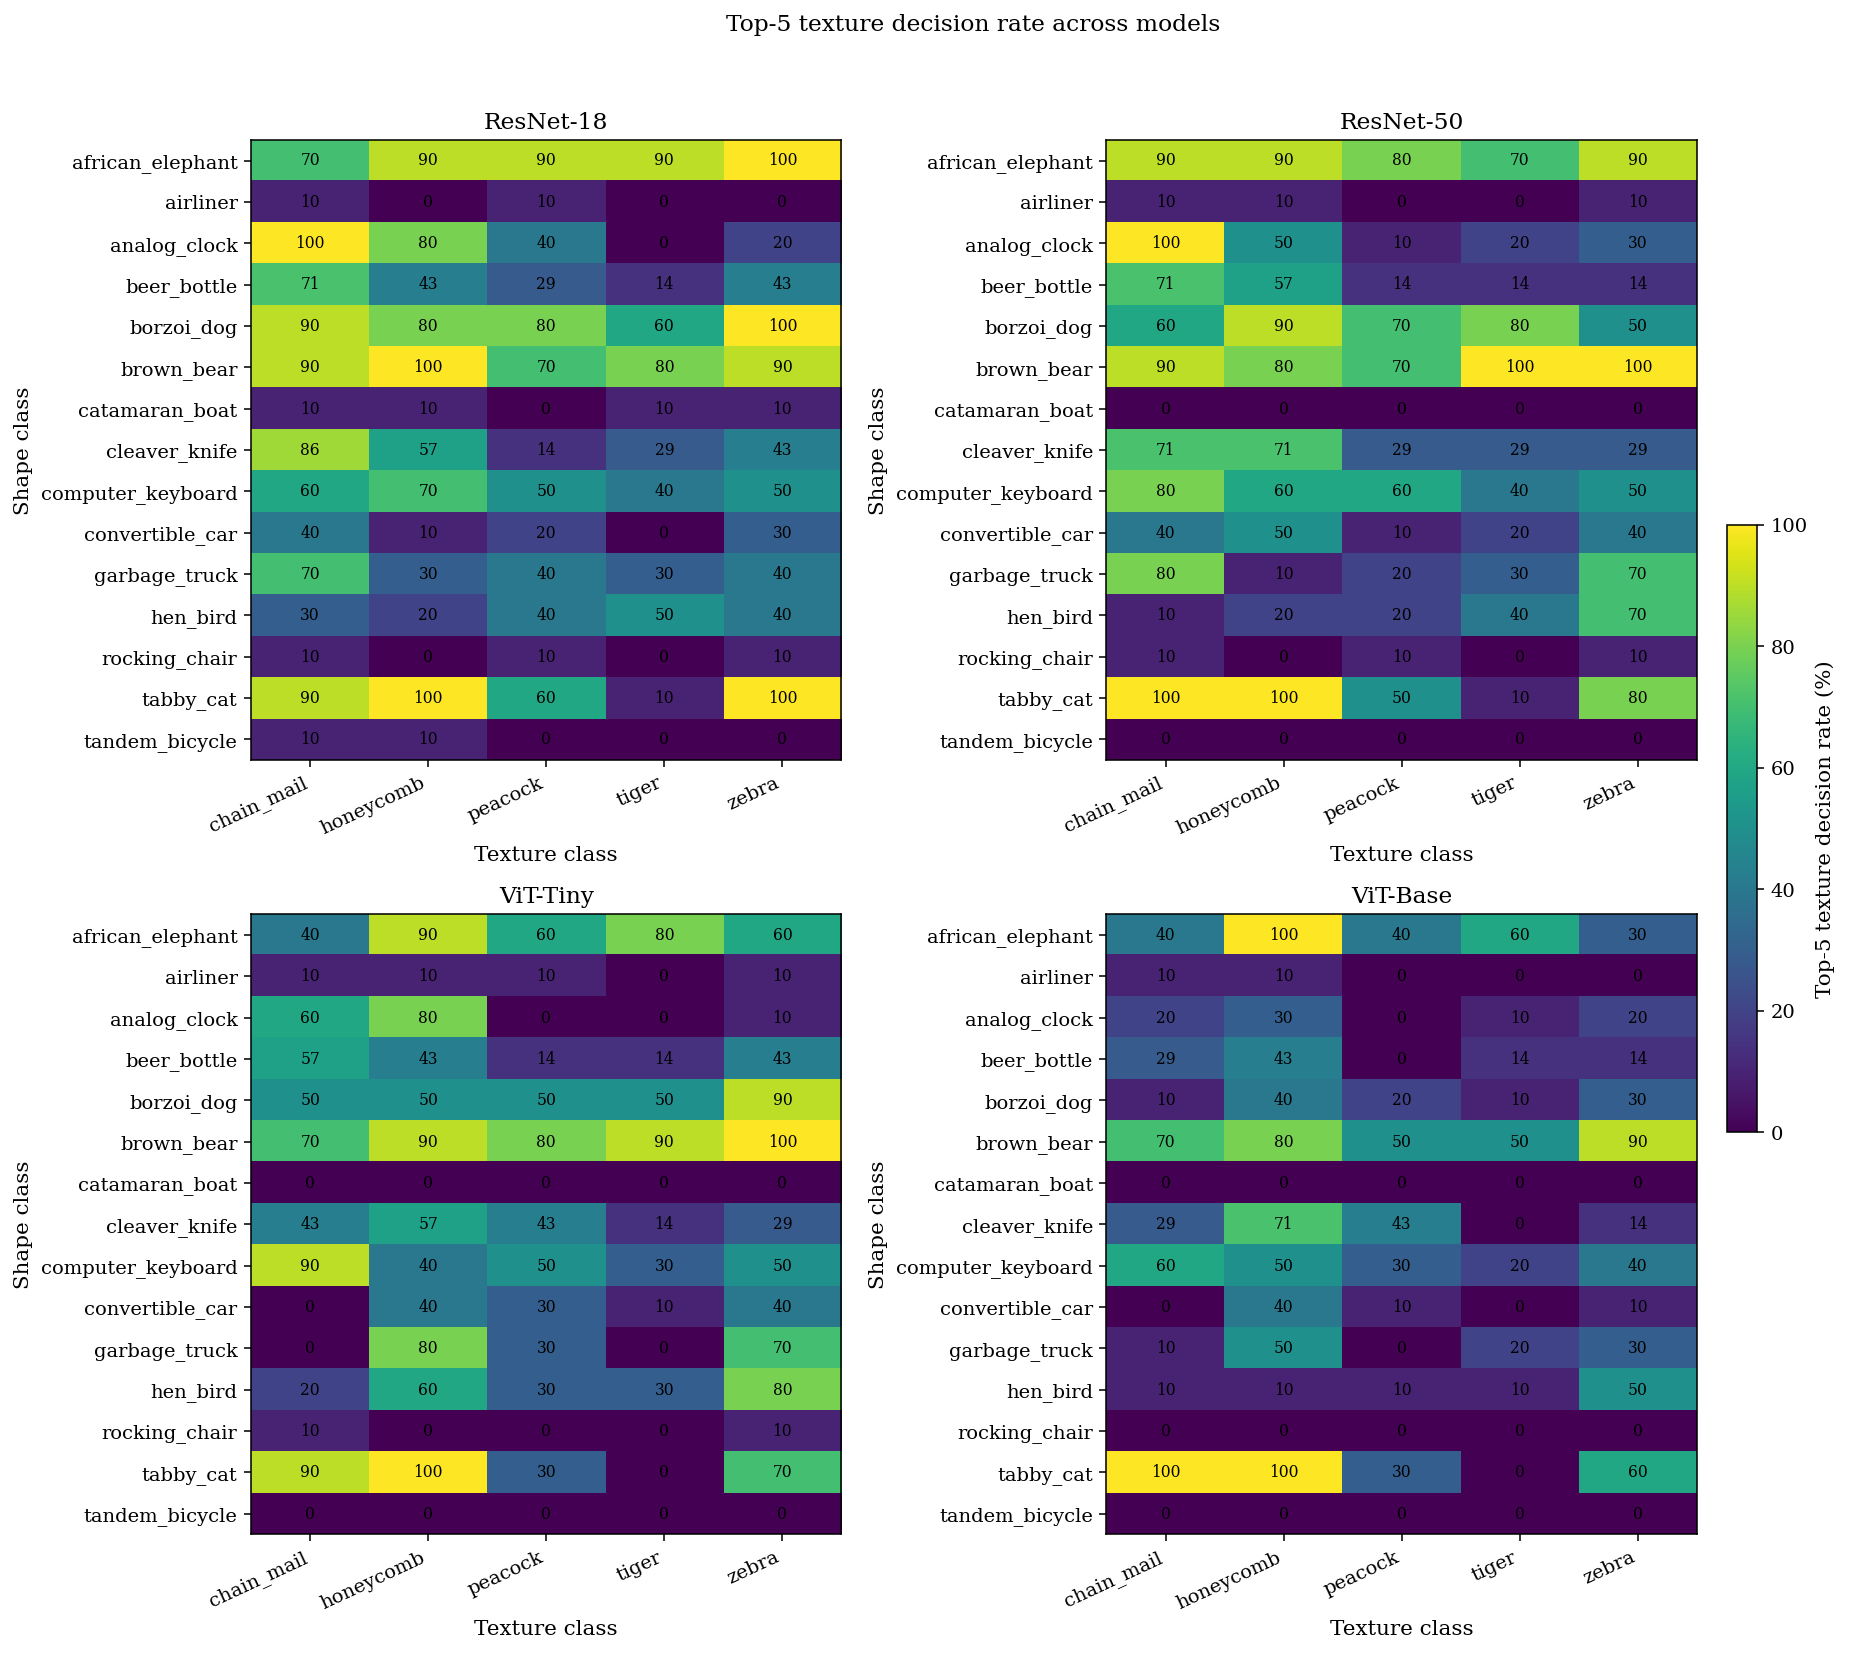

In [17]:
plot_top5_decision_heatmaps_2x2(
    df_all,
    decision_value="texture",
    title="Top-5 texture decision rate across models",
    outpath=FIG_DIR / "heatmap_top5_texture_decision_all_models.png"
)

/tmp/ipykernel_3774022/4250742780.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.88, 0.96])


Saved: /data/local/rgaisina/experiments_final/geirhos_texture_plus_edges/meta/figures_eval_all_models_1/heatmap_top5_shape_decision_all_models.png


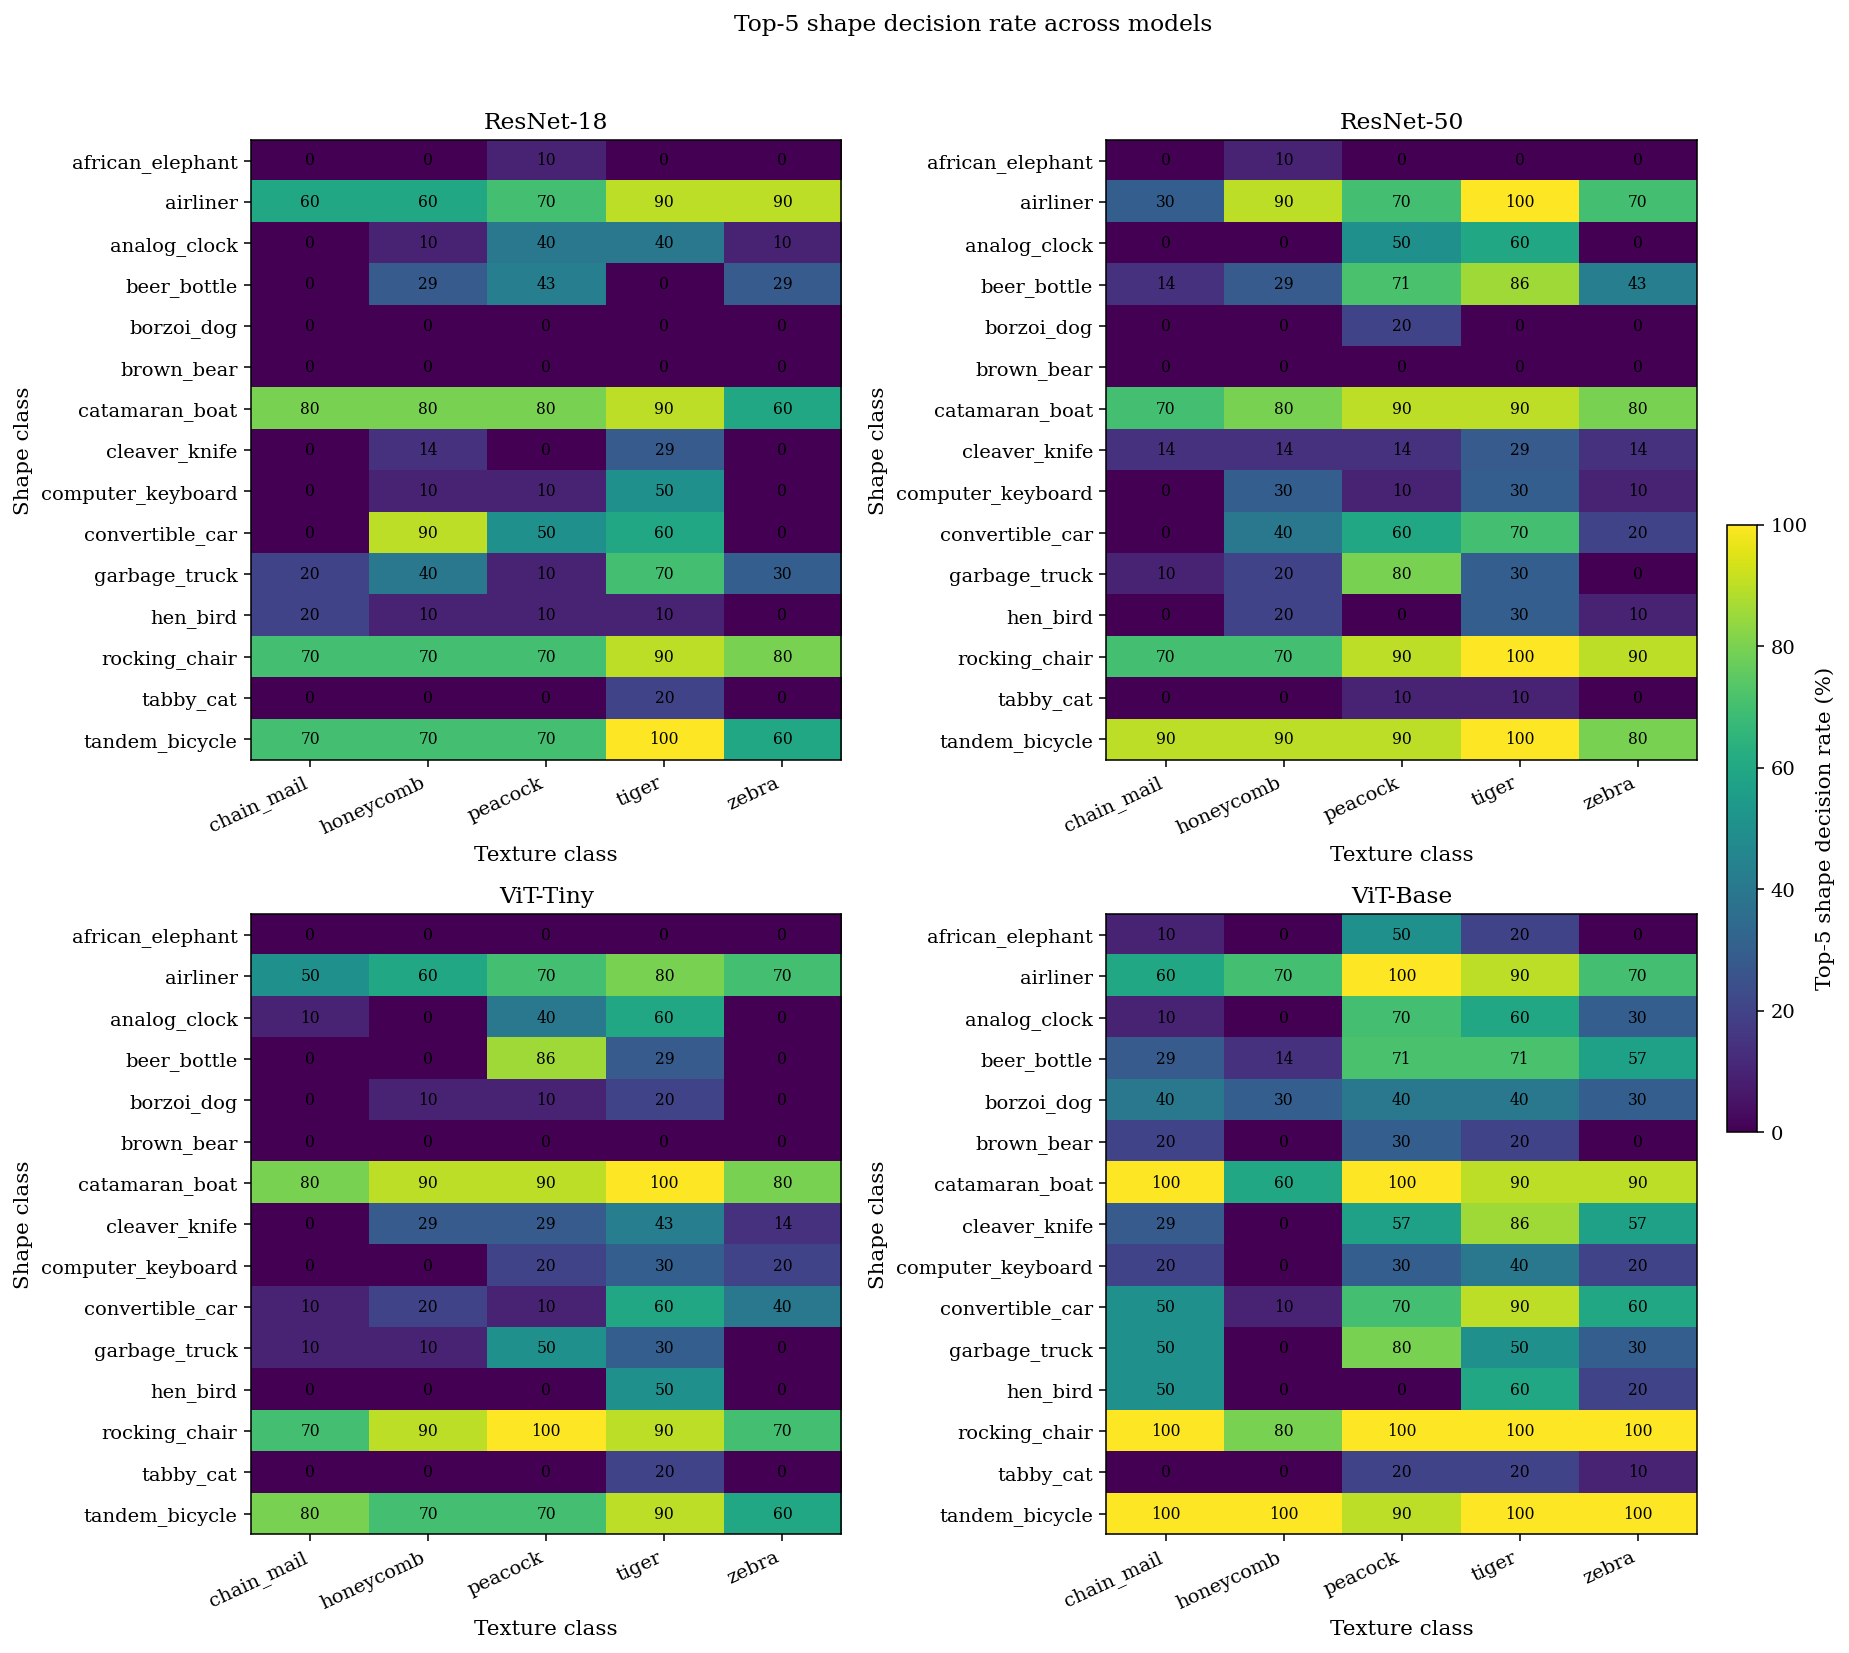

In [18]:
plot_top5_decision_heatmaps_2x2(
    df_all,
    decision_value="shape",
    title="Top-5 shape decision rate across models",
    outpath=FIG_DIR / "heatmap_top5_shape_decision_all_models.png"
)